In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import heart_failure dataset
df = pd.read_csv("heart_failure.csv")
df.sample(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
122,60.0,0,96,1,38,0,228000.0,0.75,140,0,0,95,0
78,75.0,1,203,1,38,1,283000.0,0.60,131,1,1,74,0
157,50.0,0,250,0,25,0,262000.0,1.00,136,1,1,120,0
138,62.0,0,281,1,35,0,221000.0,1.00,136,0,0,108,0
267,56.0,1,135,1,38,0,133000.0,1.70,140,1,0,244,0


### Shape

In [3]:
df.shape

(299, 13)

### Missing Values

In [4]:
#df.isnull().sum()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
df.duplicated().sum()

np.int64(0)

## Outliers

In [7]:
# Removing Outliers Function
def remove_outliers(df, column):
  q1 = df[column].quantile(0.25)
  q3 = df[column].quantile(0.75)
  iqr = q3-q1
  lower = q1 - (1.5*iqr)
  upper = q3 + (1.5*iqr)
  return df[(df[column] >= lower) & (df[column] <= upper)]

### Creatine_Phosphokinase

<Axes: xlabel='creatinine_phosphokinase'>

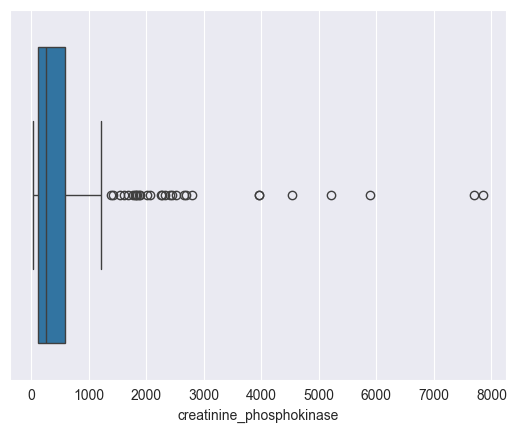

In [8]:
sns.boxplot(data=df, x="creatinine_phosphokinase")

<Axes: xlabel='creatinine_phosphokinase', ylabel='Count'>

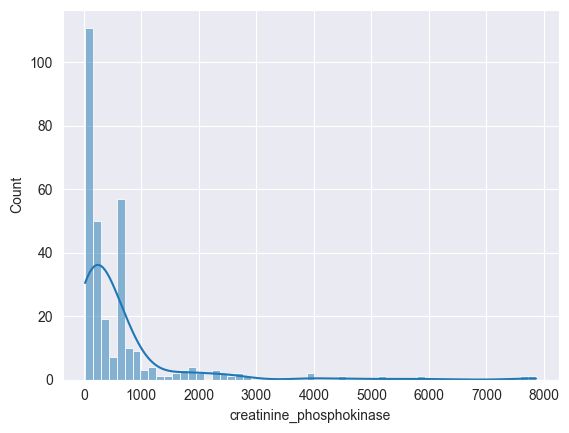

In [9]:
sns.histplot(data=df, x="creatinine_phosphokinase", kde=True)

### Ejection Fraction

<Axes: xlabel='ejection_fraction'>

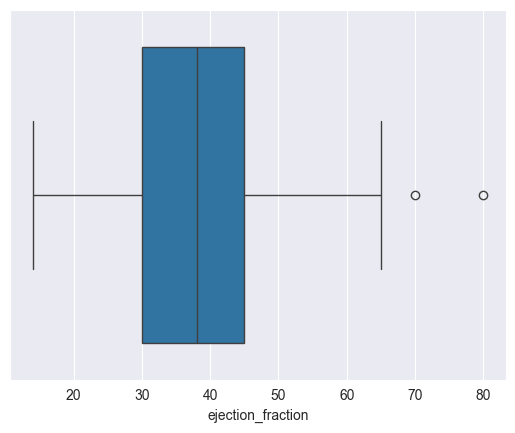

In [10]:
sns.boxplot(data=df, x="ejection_fraction")

<Axes: xlabel='ejection_fraction', ylabel='Count'>

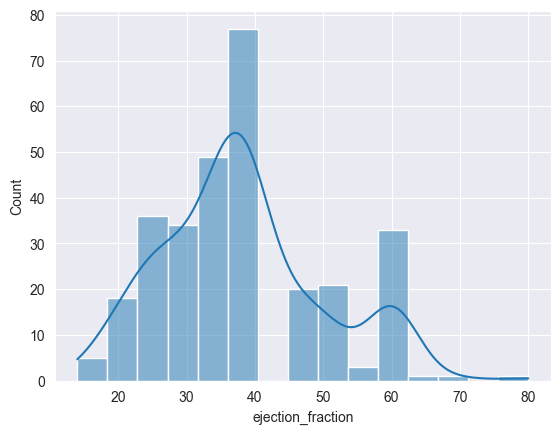

In [11]:
sns.histplot(data=df, x="ejection_fraction", kde=True)

<Axes: xlabel='ejection_fraction'>

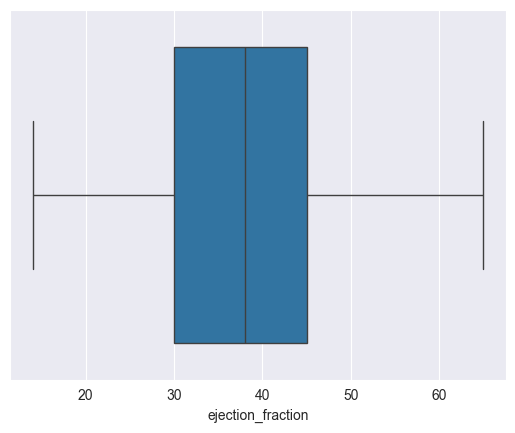

In [12]:
# Remove Outliers in Ejection fraction
cleaned = remove_outliers(df, "ejection_fraction")
sns.boxplot(data=cleaned, x="ejection_fraction")

### Platelets

<Axes: xlabel='platelets'>

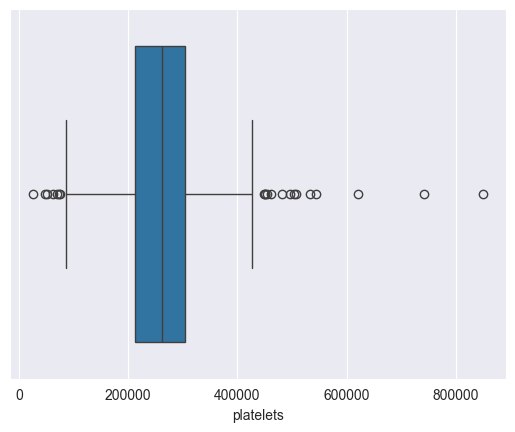

In [13]:
sns.boxplot(data=df, x="platelets")

<Axes: xlabel='platelets', ylabel='Count'>

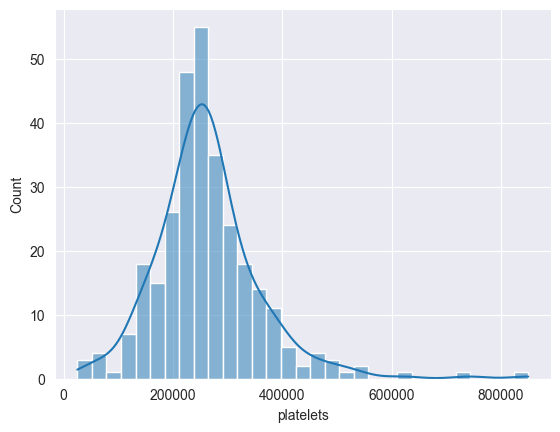

In [14]:
sns.histplot(data=df, x="platelets", kde=True)

### Serum Sodium

<Axes: xlabel='serum_sodium'>

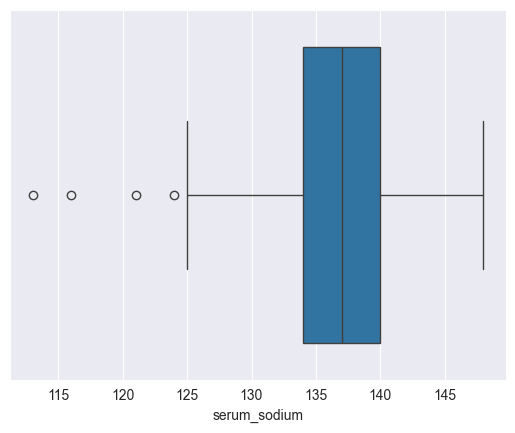

In [15]:
sns.boxplot(data=df, x="serum_sodium")

<Axes: xlabel='serum_sodium', ylabel='Count'>

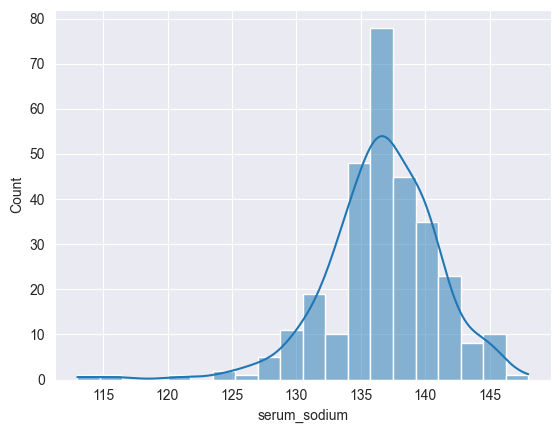

In [16]:
sns.histplot(data=df, x="serum_sodium", kde=True)

<Axes: xlabel='serum_sodium'>

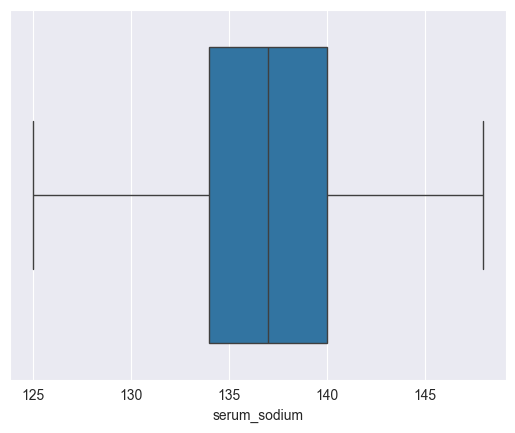

In [17]:
# Remove Outliers from Serum SOdium
cleaned = remove_outliers(df, "serum_sodium")
sns.boxplot(data=cleaned, x="serum_sodium")

<Axes: xlabel='serum_sodium', ylabel='Count'>

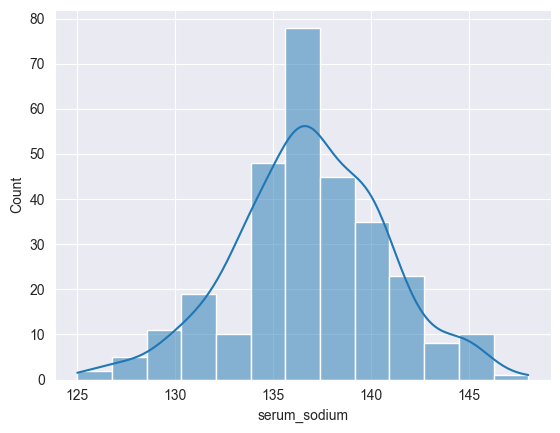

In [18]:
sns.histplot(data=cleaned, x="serum_sodium", kde=True)

## Distribution and Balance

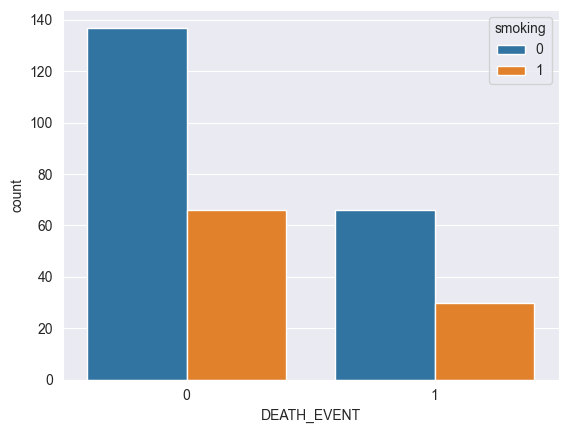

In [19]:
sns.countplot(data=df, x="DEATH_EVENT", hue="smoking")
plt.show()

## Train Test Split

In [20]:
X = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

In [22]:
X_train.shape, X_test.shape

((239, 12), (60, 12))

# Model Building

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Train on default parameters
dt = DecisionTreeClassifier(random_state=0)

In [24]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred = dt.predict(X_test)

In [26]:
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")

Accuracy Score: 0.6333333333333333
Precision Score: 0.5789473684210527
Recall Score: 0.44


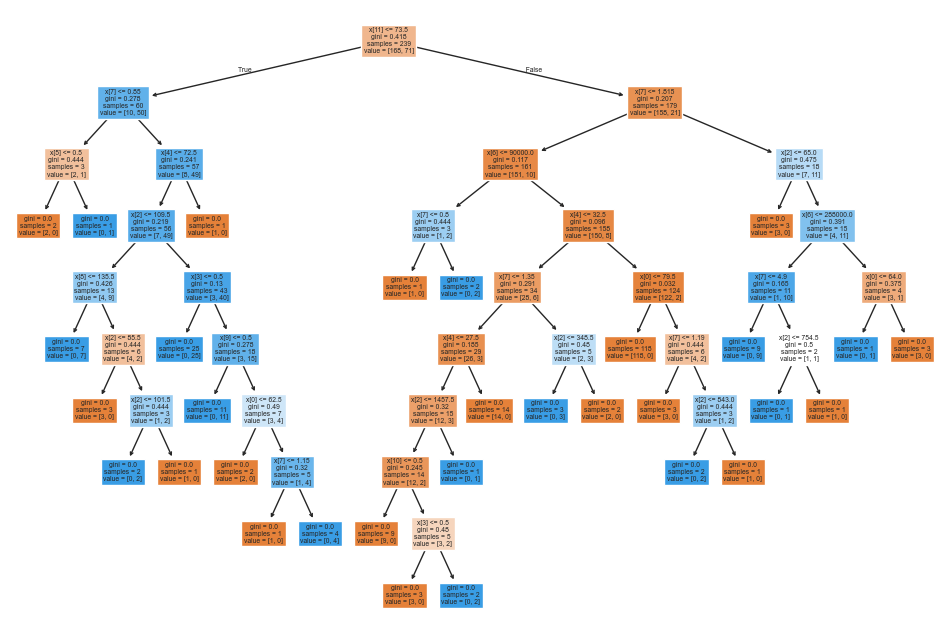

In [27]:
# Plot the tree
plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True)
plt.show()

# GridSearchCV - hyperparameter Tuning

In [28]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Max_depth
max_depth =[3, 5,6, 7, 10, None]

#min_sample_split
min_sample_split = [3, 4, 5, 8, 10, 12, 14, 20, 25, 30]

# Min_samples_leaf
min_samples_leaf = [3, 5, 6, 8, 10, 12, 15]

# max_features
max_features =  [0.2, 0.4, 0.8, 1.0]

In [29]:
param_grid = {
    "max_depth": max_depth,
    "min_samples_split": min_sample_split,
    "min_samples_leaf": min_samples_leaf,
    "max_features": max_features
}
print(param_grid)

{'max_depth': [3, 5, 6, 7, 10, None], 'min_samples_split': [3, 4, 5, 8, 10, 12, 14, 20, 25, 30], 'min_samples_leaf': [3, 5, 6, 8, 10, 12, 15], 'max_features': [0.2, 0.4, 0.8, 1.0]}


In [30]:
rf_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv = 7,
    verbose=2,
    n_jobs=-1
)

In [31]:
rf_grid.fit(X_train, y_train)

Fitting 7 folds for each of 1680 candidates, totalling 11760 fits


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [0.2, 0.4, ...], 'min_samples_leaf': [3, 5, ...], 'min_samples_split': [3, 4, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,7
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


# Training another model but with different parameters

In [32]:
dt2 = DecisionTreeClassifier(max_depth=7, max_features=0.4, min_samples_leaf=3, min_samples_split=12, random_state=0)
dt2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,12
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,0.4
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred_2 = dt2.predict(X_test)

In [34]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")

Accuracy Score: 0.6333333333333333
Precision Score: 0.5789473684210527
Recall Score: 0.44
